<a href="https://colab.research.google.com/github/eduardozurek/ia/blob/main/_006_reduccion_de_dimensiones/001_PCA_ejemplo_b%C3%A1sico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Eduardo Zurek, Ph.D.

Inteligencia Artificial

Ingeniería de Sistemas

Universidad del Norte

Mayo 17 de 2022, 2:38 p.m.

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:5: RuntimeWarning: covariance is not positive-semidefinite.
  """


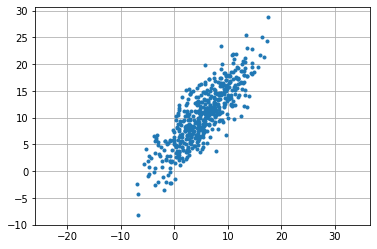

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
m = [5,10]
c = [[20,30],[20,20]]
x, y = np.random.multivariate_normal(m, c, 500).T
plt.plot(x,y,'.')
plt.axis('equal')
plt.grid()

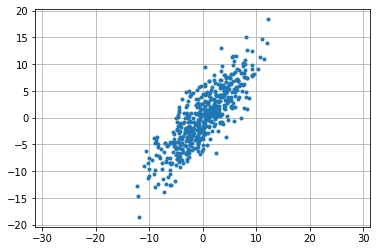

In [ ]:
from sklearn import preprocessing
datos = np.column_stack((x,y))
scaler = preprocessing.StandardScaler(with_mean=True,with_std=False).fit(datos)
datos_centrados = scaler.transform(datos)
plt.plot(datos_centrados[:,0],datos_centrados[:,1],'.')
plt.axis('equal')
plt.grid()

In [ ]:
covarianza = np.dot(datos_centrados.T,datos_centrados)

In [ ]:
covarianza

array([[10566.35479864, 10585.06858963],
       [10585.06858963, 15289.55784786]])

In [ ]:
valores, vectores = np.linalg.eig(covarianza)

In [ ]:
indice = np.argsort(-abs(valores))
valores = valores[indice]
vectores = vectores[:,indice] # vectores ordenados teniendo en cuenta la magnitud de los valores
print(valores)
print(vectores)

[23773.27046385  2082.64218265]
[[-0.62539861 -0.78030544]
 [-0.78030544  0.62539861]]


In [ ]:
valores/np.sum(valores) # varianza explicada por componente

array([0.91945199, 0.08054801])

In [ ]:
componentes = np.dot(datos_centrados,vectores)

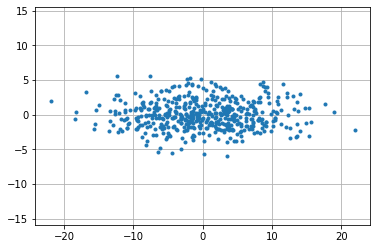

In [ ]:
plt.plot(componentes[:,0],componentes[:,1],'.')
plt.axis('equal')
plt.grid()

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2,whiten=False).fit(datos_centrados)
print(pca.explained_variance_ratio_)
print(pca.singular_values_)
print(pca.components_)
transformados = pca.fit_transform(datos_centrados)

[0.91945199 0.08054801]
[154.18583094  45.63597465]
[[ 0.62539861  0.78030544]
 [ 0.78030544 -0.62539861]]


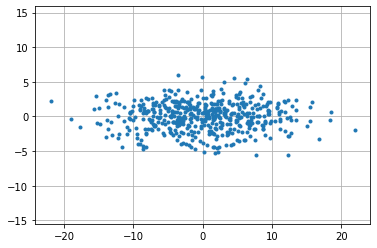

In [ ]:
plt.plot(transformados[:,0],transformados[:,1],'.')
plt.axis('equal')
plt.grid()

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: RuntimeWarning: covariance is not positive-semidefinite.
  import sys


Text(0, 0.5, 'Eje Z')

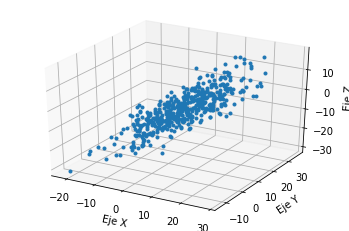

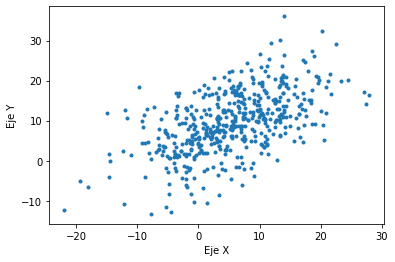

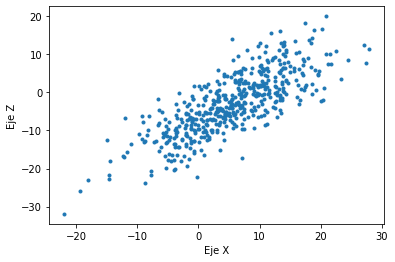

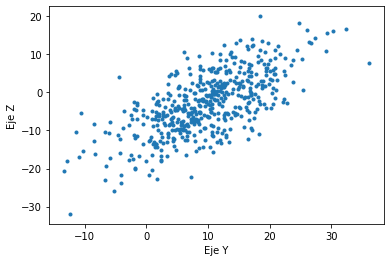

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
m = [5,10,-3]
np.random.seed(23)
c = np.random.rand(3,3)*50
c = c.T + c
x, y, z = np.random.multivariate_normal(m, c, 500).T
f = plt.figure()
ax = f.gca(projection='3d')
ax.plot(x,y,z,'.')
ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.set_zlabel('Eje Z')
plt.figure()
plt.plot(x,y,'.')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.figure()
plt.plot(x,z,'.')
plt.xlabel('Eje X')
plt.ylabel('Eje Z')
plt.figure()
plt.plot(y,z,'.')
plt.xlabel('Eje Y')
plt.ylabel('Eje Z')
#plt.axis('equal')
#plt.grid()